### EXPERIMENT 1: Feedforward Neural Network (FNN)

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical

In [2]:
# Load dataset
df = pd.read_csv("D:/2ND SEM ASSIGNMENT/DEEP LEARNING/Capstone Assignment/adult.csv/adult.csv")
print(df.head())
print(df.info())

   age  workclass  fnlwgt     education  educational-num      marital-status  \
0   25    Private  226802          11th                7       Never-married   
1   38    Private   89814       HS-grad                9  Married-civ-spouse   
2   28  Local-gov  336951    Assoc-acdm               12  Married-civ-spouse   
3   44    Private  160323  Some-college               10  Married-civ-spouse   
4   18          ?  103497  Some-college               10       Never-married   

          occupation relationship   race  gender  capital-gain  capital-loss  \
0  Machine-op-inspct    Own-child  Black    Male             0             0   
1    Farming-fishing      Husband  White    Male             0             0   
2    Protective-serv      Husband  White    Male             0             0   
3  Machine-op-inspct      Husband  Black    Male          7688             0   
4                  ?    Own-child  White  Female             0             0   

   hours-per-week native-country incom

In [3]:
# STEP 3: Handle Missing Values
df = df.replace("?", pd.NA)
df = df.dropna()

In [4]:
# STEP 4: Encode Categorical Data
le = LabelEncoder()

for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

In [5]:
# STEP 5: Split Features & Target
X = df.drop('income', axis=1)   # target column
y = df['income']


In [6]:
# STEP 6: Normalize Features
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [7]:
# STEP 7: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
# STEP 8: Build Model (FNN)
model = Sequential([
    Dense(64, activation='relu', input_shape=(X.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')   # binary classification
])

D:\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
# STEP 9: Compile Model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [10]:
# STEP 10: Train Model
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
905/905 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.8186 - loss: 0.3886 - val_accuracy: 0.8372 - val_loss: 0.3380
Epoch 2/20
905/905 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.8386 - loss: 0.3485 - val_accuracy: 0.8386 - val_loss: 0.3339
Epoch 3/20
905/905 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.8398 - loss: 0.3414 - val_accuracy: 0.8426 - val_loss: 0.3309
Epoch 4/20
905/905 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.8427 - loss: 0.3378 - val_accuracy: 0.8404 - val_loss: 0.3286
Epoch 5/20
905/905 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.8443 - loss: 0.3354 - val_accuracy: 0.8418 - val_loss: 0.3294
Epoch 6/20
905/905 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.8440 - loss: 0.3338 - val_accuracy: 0.8419 - val_loss: 0.3279
Epoch 7/20
905/905 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.8447 - loss: 0.3328 - val_accuracy: 0.8441 - val_loss: 0.3295
Epoch 8/20
905/905 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.8458 - loss: 0.3309 - val_a

In [11]:
# STEP 11: Evaluate Model
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8500 - loss: 0.3195
Test Accuracy: 0.8499723672866821


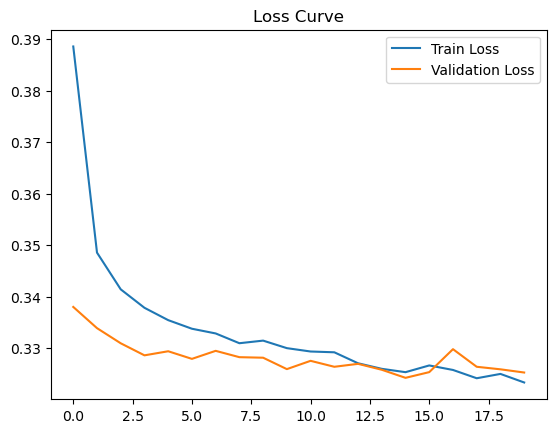

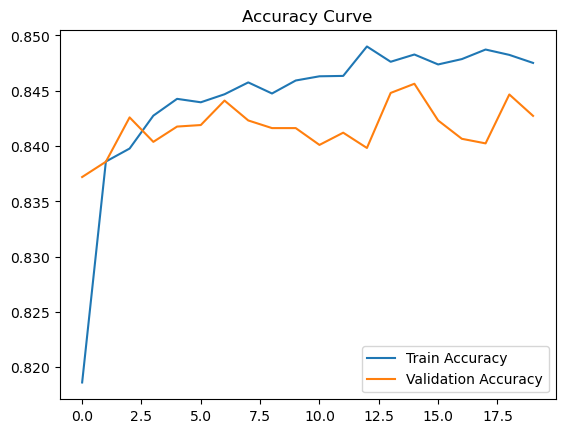

In [12]:
# STEP 12: Plot Graphs
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Curve")
plt.show()

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy Curve")
plt.show()

### Experiment 2: CNN (Fashion-MNIST)

In [13]:
# Step 1: Import Libraries
import numpy as np
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.datasets import fashion_mnist
from sklearn.metrics import classification_report, confusion_matrix


In [14]:
# Step 2: Load Dataset
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

In [15]:
# Step 3: Normalize Data
X_train = X_train / 255.0
X_test = X_test / 255.0

In [16]:
# Step 4: Reshape Data
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

In [17]:
# Step 5: Build CNN Model
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D(2,2),
    
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

D:\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
# Step 6: Compile Model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
#Step 7: Train Model
history = model.fit(X_train, y_train,
                    epochs=10,
                    batch_size=64,
                    validation_split=0.2)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 57s 68ms/step - accuracy: 0.7754 - loss: 0.6185 - val_accuracy: 0.8500 - val_loss: 0.4115
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 45s 60ms/step - accuracy: 0.8509 - loss: 0.4150 - val_accuracy: 0.8713 - val_loss: 0.3500
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 55ms/step - accuracy: 0.8718 - loss: 0.3594 - val_accuracy: 0.8860 - val_loss: 0.3069
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 48s 63ms/step - accuracy: 0.8818 - loss: 0.3230 - val_accuracy: 0.8938 - val_loss: 0.2881
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 47s 63ms/step - accuracy: 0.8916 - loss: 0.2992 - val_accuracy: 0.9007 - val_loss: 0.2714
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 48s 64ms/step - accuracy: 0.8986 - loss: 0.2787 - val_accuracy: 0.8928 - val_loss: 0.2835
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 49s 65ms/step - accuracy: 0.9046 - loss: 0.2591 - val_accuracy: 0.9059 - val_loss: 0.2581
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 203s 271ms/step - accuracy: 0.9098 - loss: 0.2467 

In [ ]:
import matplotlib.pyplot as plt

# Accuracy curve
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("CNN Accuracy Curve")
plt.show()

# Loss curve
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("CNN Loss Curve")
plt.show()

In [ ]:
# Step 8: Evaluate Model
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

In [ ]:
# Step 9: Predictions
y_pred = model.predict(X_test)
y_pred_classes = y_pred.argmax(axis=1)

In [ ]:
# Step 10: Evaluation Metrics
print(classification_report(y_test, y_pred_classes))
print(confusion_matrix(y_test, y_pred_classes))

### Experiment 3: LSTM

In [ ]:
# Step 1: Import Libraries
import numpy as np
import pandas as pd

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [ ]:
# Step 2: Load Dataset
df = pd.read_csv("D:/2ND SEM ASSIGNMENT/DEEP LEARNING/Capstone Assignment/DailyDelhiClimateTest.csv")
df.head()

In [ ]:
# Step 3: Preprocess Data
df = df.dropna()
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

data = df['meantemp'].values.reshape(-1, 1)

In [ ]:
# Step 4: Normalize Data
scaler = MinMaxScaler()
data = scaler.fit_transform(data)

In [ ]:
# Step 5: Create Sequences
def create_sequences(data, seq_length=50):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

X, y = create_sequences(data)

In [ ]:
# Step 6: Train-Test Split
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [ ]:
# Step 7: Build LSTM Model
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(X.shape[1], 1)),
    LSTM(50),
    Dense(1)
])

In [ ]:
# Step 8: Compile Model
model.compile(optimizer='adam', loss='mse')

In [ ]:
# Step 9: Train Model
history = model.fit(X_train, y_train,
                    epochs=10,
                    batch_size=32,
                    validation_split=0.1)

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("LSTM Loss Curve")
plt.show()

In [ ]:
# Step 10: Evaluate Model
loss = model.evaluate(X_test, y_test)
print("Test MSE:", loss)